In [1]:
import sys, os
sys.path.append('../../')

from utils.velocity_fields.modulation import DSM, DSMR

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

import numpy as np

from utils.shape_primitives.SuperEllipsoids import SuperEllipses 

In [2]:
def straight_ds(x, x_goal=np.array([2.0, 0.0])):
    """
    A straight line from the origin to the goal.
    """
    return x_goal - x

def draw_superellipse(ax, superellipse_obj, num_points=300, color="tab:blue", alpha=0.5):
    """
    Draw the 2D superellipse on a matplotlib Axes object.
    
    Parameters:
    - ax: matplotlib.axes.Axes
    - superellipse_obj: instance of SuperEllipses
    - num_points: number of points to plot the boundary
    - color: fill color
    - alpha: transparency
    """
    a1, a2, e1 = superellipse_obj.a1, superellipse_obj.a2, superellipse_obj.e1
    p = superellipse_obj.p
    R = superellipse_obj.R

    # Sample angle theta from 0 to 2*pi
    theta = np.linspace(0, 2 * np.pi, num_points)

    # Superellipse parametric equation
    cos_e = np.sign(np.cos(theta)) * (np.abs(np.cos(theta)) ** e1)
    sin_e = np.sign(np.sin(theta)) * (np.abs(np.sin(theta)) ** e1)
    x_ = a1 * cos_e
    y_ = a2 * sin_e
    points = np.vstack([x_, y_]).T  # shape: (num_points, 2)

    # Apply rotation and translation
    points_transformed = points @ R.T + p.reshape(1, 2)

    # Draw
    ax.fill(points_transformed[:, 0], points_transformed[:, 1], color=color, alpha=alpha)

In [3]:
# DSM: A Dynamical System Approach to Realtime Obstacle Avoidance (Autonomous Robots 2012)

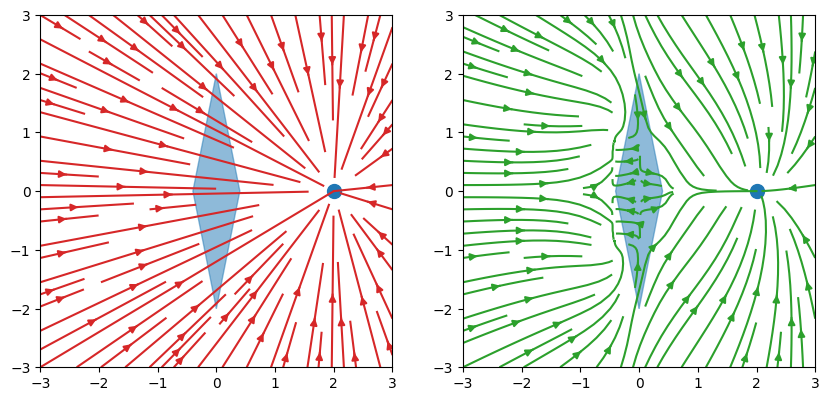

In [4]:
x_goal = np.array([2.0, 0.0])

obs1 = SuperEllipses(
    a1=0.4, 
    a2=2, 
    e1=2.0, 
    p=np.array([0.0, 0.0]), 
    R=np.eye(2)
)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
for ax in axs:
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal', adjustable='box')

draw_superellipse(axs[0], obs1, color="tab:blue", alpha=0.5)
draw_superellipse(axs[1], obs1, color="tab:blue", alpha=0.5)

# draw the velocity field streamline
x1 = np.linspace(-3, 3, 20)
x2 = np.linspace(-3, 3, 20)
X1, X2 = np.meshgrid(x1, x2)

x_cat = np.hstack([X1.reshape(-1, 1), X2.reshape(-1, 1)])
v_straight = straight_ds(x_cat, x_goal=x_goal)
dist = obs1.get_approx_sign_distance(x_cat)
grad_dir = obs1.get_grad_approx_sign_distance(x_cat)
v_modulated = DSM(
    v_straight, 
    dist, 
    grad_dir, 
    rho=1.0,
    repulsion=True
)
axs[0].streamplot(X1, X2, v_straight[:, 0].reshape(X1.shape), v_straight[:, 1].reshape(X2.shape), color='tab:red', linewidth=1.5)
axs[1].streamplot(X1, X2, v_modulated[:, 0].reshape(X1.shape), v_modulated[:, 1].reshape(X2.shape), color='tab:green', linewidth=1.5)

axs[0].scatter(x_goal[0], x_goal[1], color='tab:blue', s=100, label='Goal')
axs[1].scatter(x_goal[0], x_goal[1], color='tab:blue', s=100, label='Goal')

plt.show()


In [5]:
# DSMR: Avoiding Dense and Dynamic Obstacles in Enclosed Spaces: Application to Moving in Crowds (T-RO 2022)    

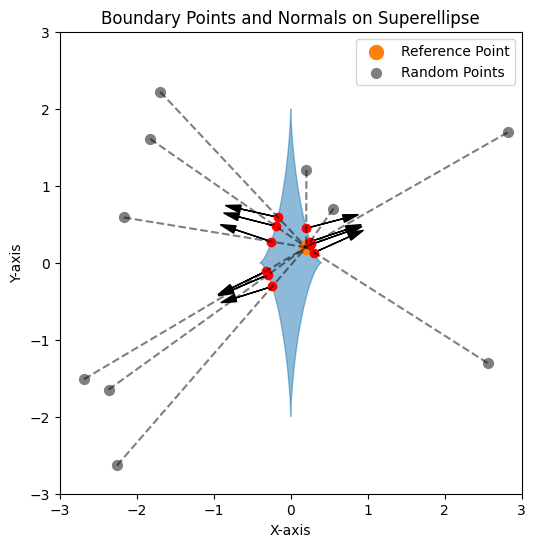

In [6]:
obs1 = SuperEllipses(
    a1=0.4, 
    a2=2, 
    e1=3.0, 
    p=np.array([0.0, 0.0]), 
    R=np.eye(2)
)

x_ref = np.array([0.2, 0.2])
random_points = np.random.uniform(-3, 3, size=(10, 2))
x_bd, normals = obs1.get_boundary_points_and_normals(random_points, x_ref)

# draw the boundary points and normals on superellipse with random points
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
draw_superellipse(ax, obs1, color="tab:blue", alpha=0.5)

for point, normal in zip(x_bd, normals):
    ax.plot(point[0], point[1], 'ro')  # boundary point
    ax.arrow(point[0], point[1], normal[0] * 0.5, normal[1] * 0.5, 
             head_width=0.1, head_length=0.2, fc='black', ec='black')  # normal vector
ax.scatter(x_ref[0], x_ref[1], color='tab:orange', s=100, label='Reference Point')

ax.scatter(random_points[:, 0], random_points[:, 1], color='tab:gray', s=50, label='Random Points')

# draw lines connecting random points to boundary points
for point in random_points:
    ax.plot([point[0], x_ref[0]], [point[1], x_ref[1]], 'k--', alpha=0.5)
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_aspect('equal', adjustable='box')
ax.legend()
plt.title("Boundary Points and Normals on Superellipse")
plt.show()

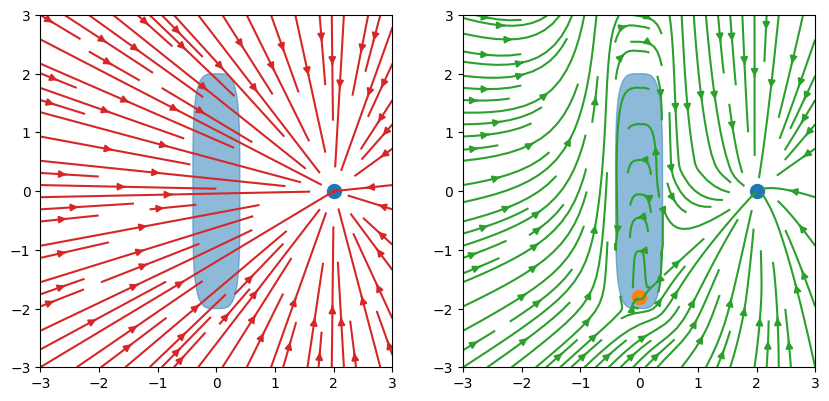

In [33]:
x_goal = np.array([2.0, 0.0])
x_ref = np.array([0.0, -1.8])

obs1 = SuperEllipses(
    a1=0.4, 
    a2=2, 
    e1=0.5, 
    p=np.array([0.0, 0.0]), 
    R=np.eye(2)
)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
for ax in axs:
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal', adjustable='box')

draw_superellipse(axs[0], obs1, color="tab:blue", alpha=0.5)
draw_superellipse(axs[1], obs1, color="tab:blue", alpha=0.5)

# draw the velocity field streamline
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)

x_cat = np.hstack([X1.reshape(-1, 1), X2.reshape(-1, 1)])
v_straight = straight_ds(x_cat, x_goal=x_goal)
# dist = obs1.get_approx_sign_distance(x_cat)
# grad_dir = obs1.get_grad_approx_sign_distance(x_cat)
x_bd, normals = obs1.get_boundary_points_and_normals(x_cat, x_ref=x_ref, bracket=[0.0, 100.0])
v_modulated = DSMR(
    v_straight, 
    x_cat, 
    x_ref,
    x_bd,
    normals, 
    rho=2.0,
    p=1.0,
    surface_friction=True,
    repulsion=True,
    c_rep=1.0
)
axs[0].streamplot(X1, X2, v_straight[:, 0].reshape(X1.shape), v_straight[:, 1].reshape(X2.shape), color='tab:red', linewidth=1.5)
axs[1].streamplot(X1, X2, v_modulated[:, 0].reshape(X1.shape), v_modulated[:, 1].reshape(X2.shape), color='tab:green', linewidth=1.5)

axs[0].scatter(x_goal[0], x_goal[1], color='tab:blue', s=100, label='Goal')
axs[1].scatter(x_goal[0], x_goal[1], color='tab:blue', s=100, label='Goal')
axs[1].scatter(x_ref[0], x_ref[1], color='tab:orange', s=100, label='Reference Point')
plt.show()


In [ ]:
# Weighted sum of DSMR

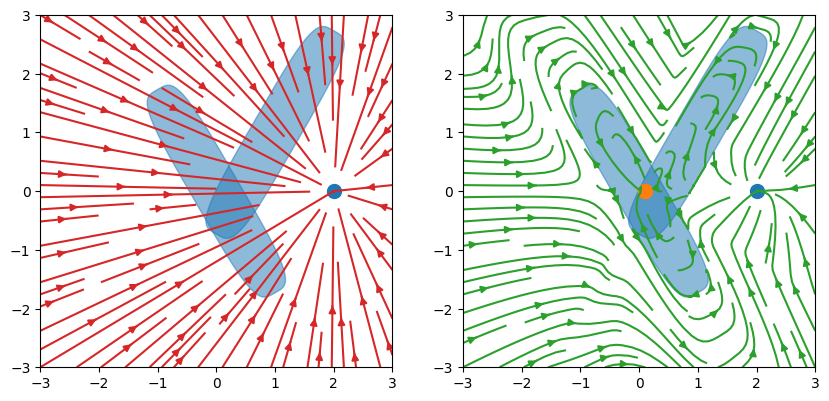

In [31]:
x_goal = np.array([2.0, 0.0])
x_ref_1 = np.array([0.1, 0.0])
x_ref_2 = x_ref_1 # np.array([0.8, 1.0]) 

theta1 = np.pi/180 * 30
obs1 = SuperEllipses(
    a1=0.4, 
    a2=2, 
    e1=0.5, 
    p=np.array([0.0, 0.0]), 
    R=np.array([[np.cos(theta1), -np.sin(theta1)],
                [np.sin(theta1), np.cos(theta1)]])
)
theta2 = -np.pi/180 * 30
obs2 = SuperEllipses(
    a1=0.4, 
    a2=2, 
    e1=0.5, 
    p=np.array([1.0, 1.0]), 
    R=np.array([[np.cos(theta2), -np.sin(theta2)],
                [np.sin(theta2), np.cos(theta2)]])
)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
for ax in axs:
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal', adjustable='box')

draw_superellipse(axs[0], obs1, color="tab:blue", alpha=0.5)
draw_superellipse(axs[0], obs2, color="tab:blue", alpha=0.5)

draw_superellipse(axs[1], obs1, color="tab:blue", alpha=0.5)
draw_superellipse(axs[1], obs2, color="tab:blue", alpha=0.5)

# draw the velocity field streamline
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
x_cat = np.hstack([X1.reshape(-1, 1), X2.reshape(-1, 1)])
v_straight = straight_ds(x_cat, x_goal=x_goal)

x_bd, normals = obs1.get_boundary_points_and_normals(x_cat, x_ref=x_ref_1, bracket=[0.0, 100.0])
v_modulated1, Gamma_1 = DSMR(
    v_straight, 
    x_cat, 
    x_ref_1,
    x_bd,
    normals, 
    rho=2.0,
    p=1.0,
    surface_friction=True,
    repulsion=True,
    c_rep=2.0,
    output_Gamma_o=True
)

x_bd, normals = obs2.get_boundary_points_and_normals(x_cat, x_ref=x_ref_2, bracket=[0.0, 100.0])
v_modulated2, Gamma_2 = DSMR(
    v_straight, 
    x_cat, 
    x_ref_2,
    x_bd,
    normals, 
    rho=2.0,
    p=1.0,
    surface_friction=True,
    repulsion=True,
    c_rep=2.0,
    output_Gamma_o=True
)
w1 = np.exp(-Gamma_1/0.1)
w2 = np.exp(-Gamma_2/0.1)
v_modulated = (w1*v_modulated1 + w2*v_modulated2) / (w1 + w2)

axs[0].streamplot(X1, X2, v_straight[:, 0].reshape(X1.shape), v_straight[:, 1].reshape(X2.shape), color='tab:red', linewidth=1.5)
axs[1].streamplot(X1, X2, v_modulated[:, 0].reshape(X1.shape), v_modulated[:, 1].reshape(X2.shape), color='tab:green', linewidth=1.5)

axs[0].scatter(x_goal[0], x_goal[1], color='tab:blue', s=100, label='Goal')
axs[1].scatter(x_goal[0], x_goal[1], color='tab:blue', s=100, label='Goal')

axs[1].scatter(x_ref_1[0], x_ref_1[1], color='tab:orange', s=100, label='Reference Point')
axs[1].scatter(x_ref_2[0], x_ref_2[1], color='tab:orange', s=100, label='Reference Point')
plt.show()